# Income and Wealth Heterogeneity in the Macroeconomy

**Original paper:** *Income and Wealth Heterogeneity in the Macroeconomy* (1998), Per Krusell and Anthony A. Smith Jr.

**Implementation author:** André Chadú.

## Model summary

The Krusell–Smith model is a heterogeneous-agent incomplete-markets economy with both idiosyncratic employment risk and aggregate productivity shocks. Households choose consumption and savings subject to a borrowing constraint, taking wages and interest rates as given. Since the cross-sectional distribution of wealth affects aggregate capital and future prices, it is in principle an aggregate state variable. Krusell and Smith show that this distribution can be approximated accurately by a low-dimensional forecasting rule for aggregate capital. This notebook will solve the household problem, simulate the economy, and iteratively estimate the perceived law of motion for aggregate capital.

In [1]:
# Run this cell once before the remaining Python cells, then restart the kernel.
# --ignore-installed overwrites the incomplete Matplotlib files without using their missing RECORD file.
%pip install --ignore-installed --no-deps --no-cache-dir matplotlib==3.11.1
%pip install --upgrade sequence-jacobian numba scipy


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.3 MB 9.1 MB/s eta 0:00:01
   --------------- ------------------------ 3.7/9.3 MB 9.5 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.3 MB 9.3 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.3 MB 9.6 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 9.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   --------------------------------- ------ 2.1/2.5 MB 9.8 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 10.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.8/12.6 MB 10.1 MB/s eta 0:00:02
   ------------ --------------------------- 3.9/12.6 MB 9.8 MB/s eta 0:00:01
   ------------------ ----


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\andre\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
error: uninstall-no-record-file

× Cannot uninstall matplotlib 3.11.1
╰─> The package's contents are unknown: no RECORD file was found for matplotlib.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps matplotlib==3.11.1


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\andre\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Aiyagari economy with aggregate uncertainty

The model extends the Aiyagari incomplete-markets economy by adding an aggregate productivity shock. Output is produced with a Cobb–Douglas technology,

$Y_t=Z_tK_t^\alpha L_t^{1-\alpha}$,

where $Z_t$ follows an aggregate Markov process, for example

$\log Z_t=\rho_Z\log Z_{t-1}+\sigma_Z\varepsilon_t$.

Households also face idiosyncratic employment or productivity risk. The aggregate shock changes factor prices and therefore affects every household's saving decision. This economy is commonly called the Krusell–Smith economy.

## Sequence-Space Jacobian (SSJ) method

We solve the Krusell–Smith economy using the Sequence-Space Jacobian (SSJ) method of Auclert, Bardóczy, Rognlie, and Straub (2021). Rather than iterating directly on the high-dimensional distributional law of motion, SSJ linearizes the equilibrium around a stationary steady state and represents transition dynamics as mappings between entire time paths.

The first step computes household Jacobians: the derivatives of aggregate household outcomes, such as consumption $C_t$ and assets $A_t$, with respect to unexpected sequences of prices and income. These objects generalize the impulse-response logic of the MIT-shock method of Boppart, Krusell, and Mitman (2018).

The second step combines household Jacobians with firm first-order conditions and market-clearing conditions. Linearized equilibrium can then be written as a system in sequences, for example

$\mathcal F\,dX=dZ$,

where $dX$ collects equilibrium responses of aggregate variables, $dZ$ is an aggregate productivity shock, and $\mathcal F$ is assembled from the model's Jacobian blocks. Solving this linear system yields impulse responses for capital, consumption, output, wages, interest rates, and the distributional consequences of aggregate shocks.

SSJ is especially useful here because it retains heterogeneous-household behavior while avoiding repeated simulation and re-estimation of a perceived aggregate law of motion.

## Sequential equilibrium

For the sequence-space formulation, we do not include the aggregate distribution as an argument of the Bellman equation. Instead, we index household problems by calendar time and take a sequence of prices $\{w_t,r_t\}_{t\geq0}$ as given. The household problem is

$V_t(a,s)=\max_{c,a'\geq\underline a}\left\{u(c)+\beta\sum_{s'\in S}\pi(s'\mid s)V_{t+1}(a',s')\right\}$,

subject to

$c+a'=w_ts+\left(1+r_t-\delta\right)a$.

The optimal policy $g_{a,t}(a,s)$ maps the current individual state into next-period assets. Given this policy, the cross-sectional distribution evolves according to the linear law of motion

$\lambda_{t+1}=\Pi_{g_{a,t}}\lambda_t, \qquad \forall t$,

where $\Pi_{g_{a,t}}$ is the transition operator induced jointly by the savings policy and the idiosyncratic Markov process. The asset market must clear in every period:

$A_t=\int_{A\times S}a\,d\lambda_t(a,s)=K_t$.

Thus, both the distribution $\lambda_t(a,s)$ and aggregate capital $K_t$ are sequences indexed by time. SSJ linearizes these sequence-space equilibrium conditions around the stationary steady state.

## SSJ: Jacobian of the perfect-foresight equilibrium

The Sequence-Space Jacobian method of Auclert, Bardóczy, Rognlie, and Straub (2021) linearizes the perfect-foresight equilibrium around a stationary steady state. Rather than resolving the full nonlinear transition after each shock, it computes derivatives of aggregate outcomes with respect to unexpected sequences of inputs and prices. These Jacobians summarize the first-order transition dynamics needed to calculate impulse responses.

## Blocks and directed acyclic graphs

SSJ writes the model as a collection of blocks. A block is a mapping from input sequences to output sequences that can be solved independently. Connecting these blocks forms a directed acyclic graph (DAG). The Jacobian of the full model is obtained by composing the Jacobians of its blocks through the chain rule.

## SSJ blocks in the Krusell–Smith model

The aggregate productivity path $Z$ is exogenous and aggregate capital $K$ is the endogenous unknown sequence. The model can be divided into three blocks:

1. **Firm block:** $(Z,K)\mapsto(r,w)$.
2. **Household block:** $(r,w)\mapsto(C,A)$, where $C_t=\int g_{c,t}(a,s)\,d\Phi_t$ and $A_t=\int g_{a,t}(a,s)\,d\Phi_t$.
3. **Market-clearing block:** $(A,K)\mapsto H\equiv A-K$.

Equilibrium requires $H_t=0$ at every date. After assembling the block Jacobians, the response of capital to a productivity shock satisfies

$J_{H,K}\,dK=-J_{H,Z}\,dZ$.

Solving this linear system yields the equilibrium paths of $K$, prices, consumption, and assets.

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch, FancyArrowPatch


fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 13)
ax.set_ylim(0, 7)
ax.axis('off')
fig.suptitle('Block representation of the Krusell–Smith model',
             fontsize=24, fontweight='bold', color='#c10c0c', y=0.96)

# Exogenous/endogenous inputs
inputs = FancyBboxPatch((0.6, 0.6), 3.0, 1.4, boxstyle='square,pad=0.05',
                        facecolor='white', edgecolor='black', linewidth=1.5)
ax.add_patch(inputs)
ax.text(2.1, 1.3, 'Exogenous: $Z$\nEndogenous: $K$', ha='center', va='center',
        fontsize=19, fontweight='bold', linespacing=1.6)

# Model blocks
firm = Circle((5.4, 4.6), 1.05, facecolor='white', edgecolor='black', linewidth=1.6)
households = Circle((9.5, 4.6), 1.25, facecolor='white', edgecolor='black', linewidth=1.6)
ax.add_patch(firm)
ax.add_patch(households)
ax.text(5.4, 4.6, "Firm's\nblock", ha='center', va='center', fontsize=20, linespacing=1.5)
ax.text(9.5, 4.6, "Households'\nblock", ha='center', va='center', fontsize=20, linespacing=1.5)

clearing = FancyBboxPatch((9.6, 0.35), 2.8, 1.35, boxstyle='square,pad=0.05',
                          facecolor='white', edgecolor='black', linewidth=1.5)
ax.add_patch(clearing)
ax.text(11.0, 1.05, 'Market clearing:\n$H \\equiv A-K$', ha='center', va='center',
        fontsize=18, linespacing=1.6)

# Arrows and their sequence-space inputs/outputs
arrow = dict(arrowstyle='->', mutation_scale=24, linewidth=2.6, color='black')
ax.add_patch(FancyArrowPatch((2.6, 2.0), (4.55, 3.9), connectionstyle='arc3,rad=-0.22', **arrow))
ax.text(3.0, 3.55, '$Z, K$', fontsize=20, fontweight='bold')
ax.add_patch(FancyArrowPatch((6.48, 4.7), (8.2, 4.7), **arrow))
ax.text(7.0, 5.05, '$r, w$', fontsize=20, fontweight='bold')
ax.add_patch(FancyArrowPatch((10.9, 4.5), (11.7, 1.85), connectionstyle='arc3,rad=-0.3', **arrow))
ax.text(11.55, 3.5, '$A, C$', fontsize=20, fontweight='bold')
ax.add_patch(FancyArrowPatch((3.85, 1.3), (9.45, 1.1), **arrow))
ax.text(6.4, 1.65, '$K$', fontsize=20, fontweight='bold')

plt.show()


ModuleNotFoundError: No module named 'matplotlib.backends.registry'

## Equilibrium Jacobians

Let aggregate asset-market residuals be $H(Z,K)=A(Z,K)-K$. Every element $H_t$ depends on the full sequences of productivity and capital, not only on their contemporaneous values. Linearizing at the steady state gives

$dH = J_{H,Z}\,dZ+J_{H,K}\,dK$.

Because equilibrium requires $dH=0$, the implicit-function theorem yields

$dK=-J_{H,K}^{-1}J_{H,Z}\,dZ$.

Thus, once the Jacobians are known, the local equilibrium response to any productivity sequence follows from one linear-system solve.

## Household Jacobians

For an aggregate outcome $X\in\{A,C\}$ and an input price $p\in\{r,w\}$, the entry $J^{X,p}_{t,s}=\partial X_t/\partial p_s$ measures the response at date $t$ to an unexpected price change at date $s$. These matrices are generally not sparse: households are forward-looking, so news about a future wage or interest-rate change alters current saving and consumption decisions. The plot below displays only the first column ($s=0$).

In [ ]:
import numpy as np
import copy
import matplotlib.pyplot as plt

from sequence_jacobian import interpolate, grids, misc, JacobianDict
from sequence_jacobian import simple, het, create_model, hetblocks

# Compatibility only: required by some package releases; it does not alter the professor's model.
from sequence_jacobian.blocks.block import Block
if hasattr(Block, 'solve_steady_state_options'):
    Block.solve_steady_state_options.setdefault('solver_kwargs', {})


@simple
def firm(K, L, Z, alpha, delta):
    r = alpha * Z * (K(-1) / L) ** (alpha - 1) - delta
    w = (1 - alpha) * Z * (K(-1) / L) ** alpha
    Y = Z * K(-1) ** alpha * L ** (1 - alpha)
    return r, w, Y


@simple
def mkt_clearing(K, A, Y, C, delta):
    asset_mkt = A - K
    I = K - (1 - delta) * K(-1)
    goods_mkt = Y - C - I
    return asset_mkt, goods_mkt, I


def household_init(a_grid, e_grid, r, w, gamma):
    coh = (1 + r) * a_grid[np.newaxis, :] + w * e_grid[:, np.newaxis]
    Va = (1 + r) * (0.1 * coh) ** (-gamma)
    return Va


@het(exogenous='Pi', policy='a', backward='Va', backward_init=household_init)
def hh(Va_p, a_grid, y, r, beta, gamma):
    uc_nextgrid = beta * Va_p
    c_nextgrid = uc_nextgrid ** (-1 / gamma)
    coh = (1 + r) * a_grid[np.newaxis, :] + y[:, np.newaxis]
    a = interpolate.interpolate_y(c_nextgrid + a_grid, coh, a_grid)
    misc.setmin(a, a_grid[0])
    c = coh - a
    Va = (1 + r) * c ** (-gamma)
    return Va, a, c


def make_grid(rho_e, sd_e, nE, amin, amax, nA):
    e_grid, _, Pi = grids.markov_rouwenhorst(rho=rho_e, sigma=sd_e, N=nE)
    a_grid = grids.agrid(amin=amin, amax=amax, n=nA)
    return e_grid, Pi, a_grid



def income(w, e_grid):
    y = w * e_grid
    return y


household = hh.add_hetinputs([income, make_grid])
ks_model = create_model([household, firm, mkt_clearing], name='Krusell-Smith')

calibration = {
    'gamma': 1.0, 'delta': 0.025, 'alpha': 0.33, 'rho_e': 0.966,
    'sd_e': 0.50, 'L': 1.0, 'nE': 7, 'nA': 500, 'amin': 0.0, 'amax': 200.0,
    'beta': 0.96, 'Z': 1.0,
}
ss = ks_model.solve_steady_state(
    calibration,
    unknowns={'K': (8.0, 16.0)},
    targets={'asset_mkt': 0.0},
    solver='hybr',
)
print(f"Steady state: K = {ss['K']:.3f}, r = {ss['r']:.4f}, w = {ss['w']:.4f}")


In [ ]:
# Heterogeneous-agent Jacobians. Column zero is the response to an unexpected shock at t = 0.
T = 500
J_ha = household.jacobian(ss, inputs=['r', 'w'], T=T)

responses = [
    ('Savings $A_t$ to $r$', J_ha['A']['r'][:, 0]),
    ('Consumption $C_t$ to $r$', J_ha['C']['r'][:, 0]),
    ('Consumption $C_t$ to $w$', J_ha['C']['w'][:, 0]),
    ('Savings $A_t$ to $w$', J_ha['A']['w'][:, 0]),
]

dark_red = '#8B0000'
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
for ax, (title, response) in zip(axes.flat, responses):
    ax.plot(np.arange(T), response, color=dark_red, lw=2.4, label='Shock at $t=0$')
    ax.axhline(0, color='0.55', lw=0.8)
    ax.set_title(title, fontsize=14)
    ax.grid(alpha=0.35, ls='--')
    ax.legend(frameon=False)

for ax in axes[-1, :]:
    ax.set_xlabel('Quarters')
fig.supylabel('Response to a one-unit price shock')
fig.suptitle('Household Jacobians: Krusell–Smith model', fontsize=17, y=0.98)
fig.tight_layout()
plt.show()


## Fake-news algorithm

Computing a heterogeneous-agent Jacobian column by column would require a new backward solution for policies and a new forward propagation of the distribution for every shock date. The fake-news algorithm avoids this repetition.

For a shock that is announced at date $0$ but affects prices only at date $s$, households revise their policies through a single backward iteration. The associated change in the distribution is then propagated forward using the steady-state transition operator. Combining these policy and distribution effects recursively recovers every entry of the Jacobian.

The call `household.jacobian(...)` above uses this algorithm internally. Once these household Jacobians are available, the general-equilibrium response to a technology shock follows from composition of the model blocks and one linear-system solve.

## Impulse response functions

Following the implementation in Tomás Martinez's teaching code, we obtain the general-equilibrium Jacobian with $Z$ as the exogenous input, $K$ as the unknown sequence, and asset-market clearing as the target. We then multiply the Jacobian by AR(1) technology shocks with a one-percent impact at date $0$.

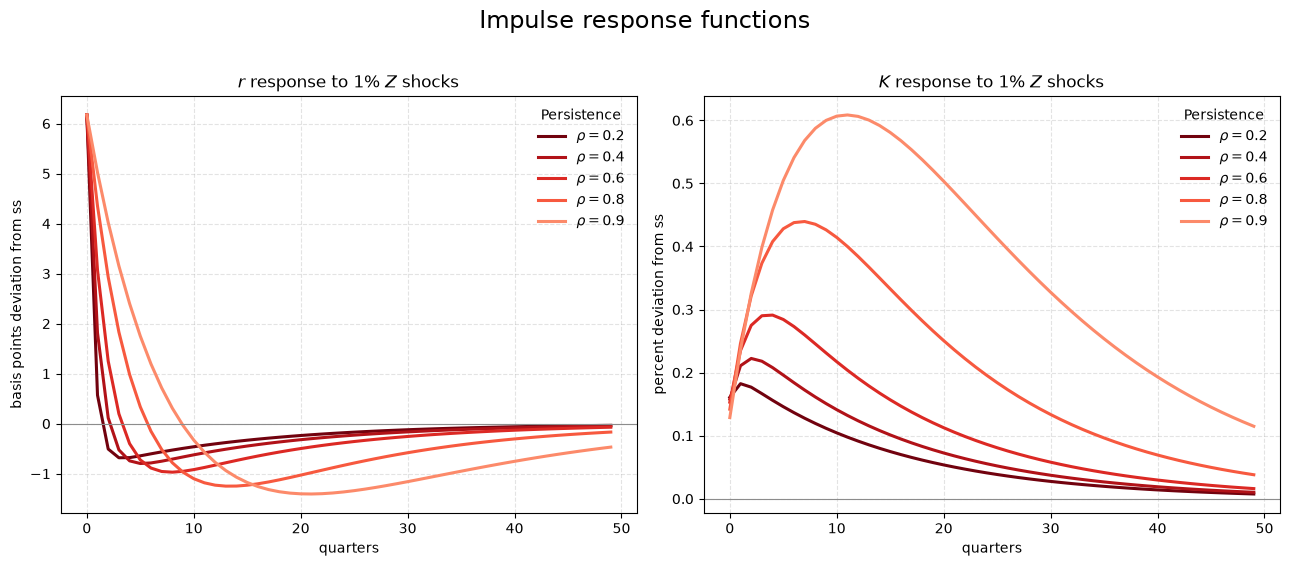

In [6]:
# General-equilibrium Jacobian and IRFs (following Martinez's SSJ implementation).
T_irf = 300
inputs = ['Z']
unknowns = ['K']
targets = ['asset_mkt']

G = ks_model.solve_jacobian(ss, unknowns, targets, inputs, T=T_irf)

# A 1% technology shock at t=0 for several AR(1) persistence values.
rhos = np.array([0.2, 0.4, 0.6, 0.8, 0.9])
dZ = 0.01 * ss['Z'] * rhos ** np.arange(T_irf)[:, np.newaxis]
dr = G['r']['Z'] @ dZ
dK = G['K']['Z'] @ dZ

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
quarters = np.arange(50)
colors = plt.cm.Reds(np.linspace(0.98, 0.40, len(rhos)))

for j, rho in enumerate(rhos):
    axes[0].plot(quarters, 10000 * dr[:50, j], color=colors[j], lw=2.2, label=fr'$\rho={rho:.1f}$')
axes[0].axhline(0, color='0.55', lw=0.8)
axes[0].set_title(r'$r$ response to 1% $Z$ shocks')
axes[0].set_xlabel('quarters')
axes[0].set_ylabel('basis points deviation from ss')
axes[0].grid(alpha=0.35, ls='--')
axes[0].legend(title='Persistence', frameon=False)

for j, rho in enumerate(rhos):
    axes[1].plot(quarters, 100 * dK[:50, j] / ss['K'], color=colors[j], lw=2.2, label=fr'$\rho={rho:.1f}$')
axes[1].axhline(0, color='0.55', lw=0.8)
axes[1].set_title(r'$K$ response to 1% $Z$ shocks')
axes[1].set_xlabel('quarters')
axes[1].set_ylabel('percent deviation from ss')
axes[1].grid(alpha=0.35, ls='--')
axes[1].legend(title='Persistence', frameon=False)

fig.suptitle('Impulse response functions', fontsize=17, y=1.02)
fig.tight_layout()
plt.show()


## References

- Aiyagari, S. R. (1994). *Uninsured Idiosyncratic Risk and Aggregate Saving*. *Quarterly Journal of Economics*, 109(3), 659–684.
- Storesletten, K., Telmer, C. I., & Yaron, A. (2004). *Consumption and Risk Sharing over the Life Cycle*. *Journal of Monetary Economics*, 51(3), 609–633.
- Krusell, P., & Smith, A. A., Jr. (1998). *Income and Wealth Heterogeneity in the Macroeconomy*. *Journal of Political Economy*, 106(5), 867–896.
- Auclert, A., Bardóczy, B., Rognlie, M., & Straub, L. (2021). *Using the Sequence-Space Jacobian to Solve and Estimate Heterogeneous-Agent Models*. *Econometrica*, 89(5), 2375–2408.
- Martinez, T. R. *Krusell–Smith using Sequence-Space Jacobian (Python teaching code and lecture notes)*. [Course material](https://tomasrm.github.io/teaching/advmacro/KS_seq_space_jac.ipynb).
